global phase: 0
     ┌─────────┐┌────┐┌─────────┐ ░                                  »
q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─░───────────────────────────────■──»
     ├─────────┤├────┤├─────────┤ ░ ┌─────────┐┌────┐┌─────────┐┌─┴─┐»
q_1: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─░─┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ X ├»
     ├─────────┤├────┤├─────────┤ ░ ├─────────┤├────┤├─────────┤└───┘»
q_2: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─░─┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─────»
     ├─────────┤├────┤├─────────┤ ░ ├─────────┤├────┤├─────────┤     »
q_3: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─░─┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─────»
     └─────────┘└────┘└─────────┘ ░ └─────────┘└────┘└─────────┘     »
c: 4/════════════════════════════════════════════════════════════════»
                                                                     »
«                                                                       »
«q_0: ──────────────────────────────────────────────────────────────────»
«     ┌─────────┐┌────┐┌─────────┐                     

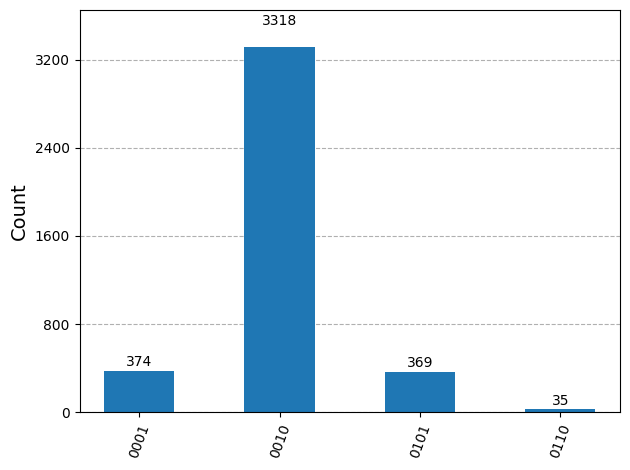

In [ ]:
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise import pauli_error

# ============================================================
# PARAMETERS
# ============================================================

shots = 4096

# Bit flip probability
p = 0.9


# ==========================================================
# Dense Coding using 4 qubit Cluster State
# ==========================================================
qc = QuantumCircuit(4,4)

# ----------------------------------------------------------
# Cluster State Preparation
# ----------------------------------------------------------

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.barrier()
qc.cz(0,1)
qc.cz(1,2)
qc.cz(2,3)
qc.barrier()
qc.h(0)
qc.h(3)
qc.barrier()

# ============================================================
# ALICE ENCODING
#----------------------------------------------------------

message = "0110"  # 0000,0001,0010,0011,0100,0101,0110,0111,1000,1001,1010,1011,1100,1101,1110,1111

if message == "0000":
    pass

elif message == "1010":
    qc.x(1)

elif message == "1110":
    qc.y(1)

elif message == "0100":
    qc.z(1)

elif message == "1000":
    qc.x(0)

elif message == "0010":
    qc.x(0)
    qc.x(1)

elif message == "0110":
    qc.x(0)
    qc.y(1)

elif message == "1100":
    qc.x(0)
    qc.z(1)

qc.barrier()
# ============================================================
# NOISE CHANNEL
# Identity gates are inserted only so that noise model acts only during transmission of qubits from alice to bob.
# ============================================================

qc.id(0)
qc.id(1)

qc.barrier()

# ----------------------------------------------------------
# Bob Decoding
# ----------------------------------------------------------

qc.h(0)
qc.h(3)
qc.barrier()

qc.cz(2,3)
qc.cz(1,2)
qc.cz(0,1)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.barrier()

qc.measure([0,1,2,3],[0,1,2,3])

# ============================================================
# BIT-PHASE FLIP NOISE MODEL
# ============================================================

bit_phase_flip = pauli_error([
    ('Y', p),
    ('I', 1-p)
])

noise_model = NoiseModel()

for gate in ['id']:
    noise_model.add_all_qubit_quantum_error(
        bit_phase_flip,
        [gate]
    )


backend = AerSimulator(noise_model=noise_model)

tqc = transpile(qc, backend, optimization_level=0)
print(tqc)

result = backend.run(
    tqc,
    shots=shots
).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

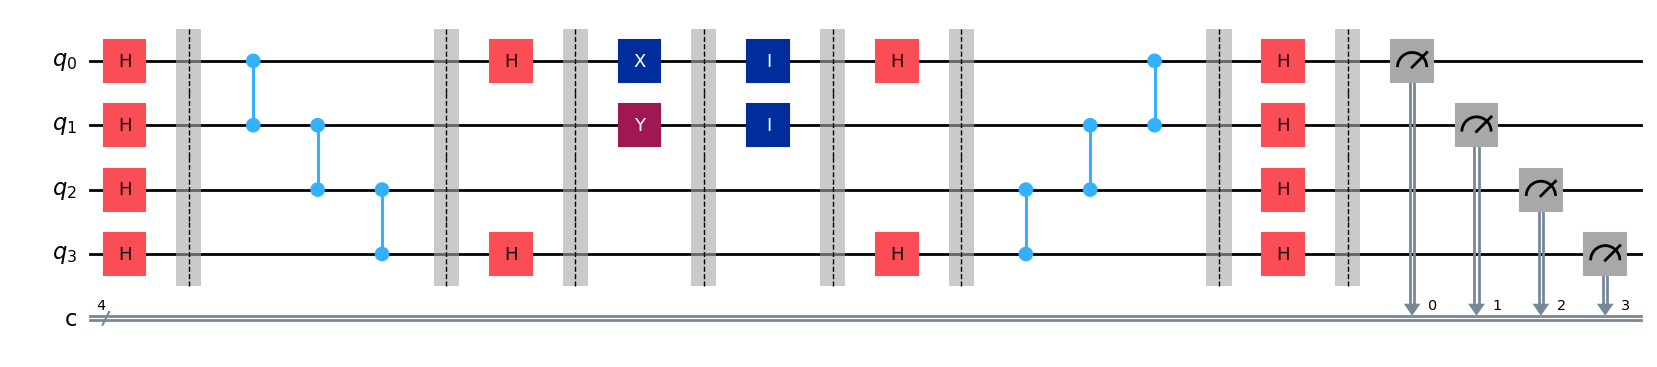

In [13]:
qc.draw(output="mpl")

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ranga\AppData\Local\Temp\ipykernel_18776\4125684838.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Noise parameter (0 ≤ $\eta_F$ ≤ 1)', fontsize=12)


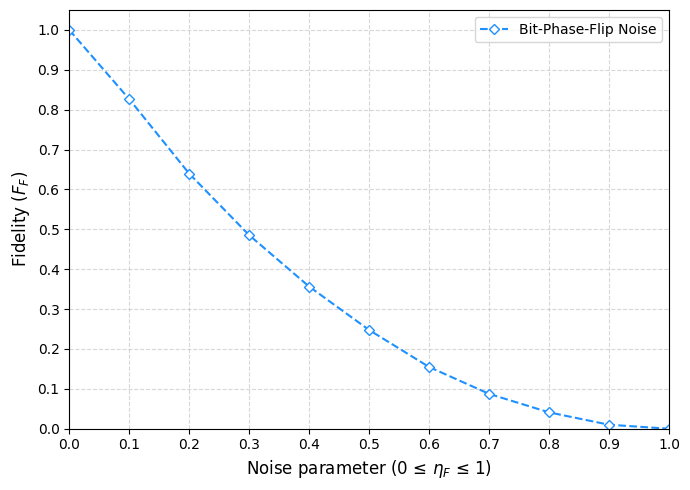

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# Data
# ================================

x = np.array([0.0, 0.1, 0.2, 0.3, 0.4,
              0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

y = np.array([1.0,
              0.82641,
              0.6396484,
              0.485351,
              0.356445,
              0.2475585,
              0.154785,
              0.087402,
              0.041015,
              0.0100097,
              0.0])


plt.figure(figsize=(7,5))

plt.plot(
    x,
    y,
    color='dodgerblue',
    linestyle='--',
    marker='D',
    markersize=5,
    markerfacecolor='white',
    linewidth=1.5,
    label='Bit-Phase-Flip Noise'
)


plt.xlim(0,1)
plt.ylim(0,1.05)

plt.xticks(np.arange(0,1.1,0.1))
plt.yticks(np.arange(0,1.1,0.1))

plt.xlabel('Noise parameter (0 ≤ $\eta_F$ ≤ 1)', fontsize=12)
plt.ylabel('Fidelity ($F_F$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(frameon=True)

plt.tight_layout()

plt.show()